In [1]:
import matplotlib.pyplot as plt
import torch
from fontTools.misc.py23 import tounicode

from classifier import *
import os, random

from collections import Counter


In [2]:
print("cwd", os.getcwd())

cwd C:\Beryllium Base\WORKSPACES\MTECH\dl-vehicles\experiments


In [3]:
model = SimpleCNN(dtype=torch.float32,
                  h_conv=[16, 32, 64],
                  h_fc=[128, 128],
                  add_pools=False,
                  c_conv={'kernel_size': 3, 'stride': 1, 'padding': 0},
                  )
print(model)
print(measure_size(model))

SimpleCNN(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (3): ReLU()
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (5): ReLU()
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=43264, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=128, bias=True)
  (10): ReLU()
  (11): Linear(in_features=128, out_features=5, bias=True)
)
21.285527229309082


In [4]:
dir_dataset = OIDv6Dataset(hard_limit=100, dtype=np.float32)
pipe_dataset = PipelinedDataset(dir_dataset, process_sample)
dataloader = DataLoader(pipe_dataset, batch_size=16)

In [5]:
len(dir_dataset)

100

In [6]:
try:
    print(len([_ for _ in dataloader]))
except Exception as e:
    print(e)

488


In [7]:
freqs: dict[int, int] = {}

for sample in dataloader:
    for label in sample[1]:
        label = int(label.argmax())
        freqs[label] = freqs.get(label, 0) + 1

counter = Counter(freqs)

In [8]:
counter[4] / sum(v for k, v in counter.items())

0.30823162814853283

In [9]:
print(next(iter(dataloader))[0].max())

tensor(1.0115)


In [10]:
huh = nn.CrossEntropyLoss()

class SoftCrossEntropyLoss(nn.Module):
    def forward(self, logits, targets):
        # targets = targets / targets.sum(dim=1, keepdim=True)
        # log_probs = torch.log_softmax(logits, dim=1)
        # return -(targets * log_probs).sum(dim=1).mean()

        targets = targets.argmax(axis=1)
        return huh(logits, targets)

In [11]:
try:
    spa = SoftCrossEntropyLoss()
    logits = np.random.rand(16, 5)
    targets = logits.argmax(axis=1)
    # print(logits, targets)
    print(spa(torch.asarray(logits), torch.asarray(logits)))
except Exception as e:
    print(e)

tensor(1.2786, dtype=torch.float64)


In [12]:
trainer = Trainer(
    model=model,
    train_dataloader=dataloader,
    # criterion = nn.CrossEntropyLoss(ignore_index=0),
    criterion=SoftCrossEntropyLoss(),
    optimizer=lambda params: torch.optim.Adam(params, lr=0.003),
    epochs=5,
)

In [32]:
trainer.train()

Epoch:  1/ 5    Train Loss: 1.39    TTS: 16.78    ETA: 67.10
Epoch:  2/ 5    Train Loss: 1.39    TTS: 32.57    ETA: 48.85
Epoch:  3/ 5    Train Loss: 1.39    TTS: 48.18    ETA: 32.12
Epoch:  4/ 5    Train Loss: 1.39    TTS: 63.56    ETA: 15.89
Epoch:  5/ 5    Train Loss: 1.39    TTS: 79.02    ETA: 0.00


tensor([0., 1., 0., 0., 0.])
index 1
class truck


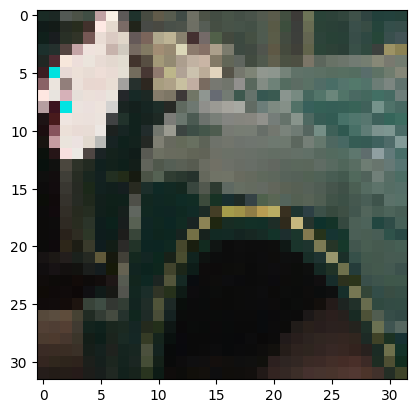

In [29]:
test_sample = None
for sample in dataloader:
    test_sample = sample
    if random.randint(1, 10) == 1:
        break

sample_i = (255*test_sample[0][0].detach().numpy().transpose(1, 2, 0)).astype(np.uint8)
print(test_sample[1][0])
print("index", test_sample[1][0].argmax().detach().item())
print("class", idx_to_class[int(test_sample[1][0].argmax().detach().item())])

try:
    plt.imshow(sample_i)
except Exception as e:
    print(e)
    pass

In [31]:
with torch.no_grad():
    # print(test_sample[0][0:1].shape)
    thing = model(test_sample[0][0:1])
    print(thing)
    print(thing.mean(), thing.std())
    print(thing.argmax())

tensor([[-0.1010,  0.1563, -0.0478, -3.6336,  0.2830]])
tensor(-0.6686) tensor(1.6647)
tensor(4)


In [50]:
with torch.no_grad():
    # print(test_sample[0][0:1].shape)
    thing = model(test_sample[0][0:1])
    print(thing)
    print(thing.argmax())

tensor([[-1.8879e-01,  6.3321e-03, -3.6987e-01, -1.5465e+01,  1.2206e-01]],
       dtype=torch.float64)
tensor(4)


In [42]:
try:
    with torch.no_grad():
        # print(test_sample[0][0:1].shape)
        thing = model(test_sample[0])
        # print(thing)
        print(thing.argmax(axis=1))
except:
    pass

tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])
